# HeritageNet — Full Model Dashboard

Comprehensive, live-computed analysis of the champion model. Everything here is
computed fresh from the checkpoint and test set — no hardcoded numbers.

**Sections**
1. Setup & load
2. Headline metrics (accuracy, macro-F1, weighted-F1, top-k)
3. Per-class F1 — sorted bar chart
4. Per-class F1 vs training-set size — the *data-limited* evidence
5. Precision vs recall scatter (magnets vs escapees)
6. Confusion matrix (row-normalized)
7. Confidence analysis (correct vs wrong)
8. Threshold / selective-accuracy trade-off
9. Strategy comparison (frozen / partial / full)

> Run: **Restart & Run All**.

In [1]:
# 1 · Setup & load ------------------------------------------------------
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import json, numpy as np, torch
import torch.nn.functional as F
from pathlib import Path
from collections import Counter
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib import cm as mcm
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report, confusion_matrix)

from heritagenet.data.datamodule import HeritageDataModule
from heritagenet.models.factory import build_model
from heritagenet.utils.device import get_device

%matplotlib inline

# ---- style (dark, brass accent) ----
plt.rcParams.update({
    'figure.dpi':120, 'figure.facecolor':'#181a25', 'axes.facecolor':'#1f2230',
    'axes.edgecolor':'#2f3346', 'axes.labelcolor':'#ece7dd', 'text.color':'#ece7dd',
    'xtick.color':'#9a9caa', 'ytick.color':'#9a9caa', 'axes.titlecolor':'#ece7dd',
    'font.size':10, 'axes.grid':True, 'grid.color':'#2a2e40', 'grid.alpha':.6,
})
BRASS='#d0a94e'; JADE='#5f9c92'; ROSE='#c9736b'; GOOD='#6fae7d'; WARN='#d9a24b'; BAD='#c9615a'

CKPT = 'checkpoints/phase2_86acc_FINAL.pt'   # champion; change if needed
MODEL = 'mobilenet_v3_small'
device = get_device()

dm = HeritageDataModule(root='data', batch_size=32).setup()
classes = dm.classes
model = build_model(MODEL, num_classes=dm.num_classes, pretrained=False, freeze_backbone=False)
state = torch.load(CKPT, map_location=device)
model.load_state_dict(state['model_state'] if 'model_state' in state else state)
model.to(device).eval()
print(f'loaded {CKPT} | {dm.num_classes} classes | {len(dm.test_dataset)} test images')

loaded checkpoints/phase2_86acc_FINAL.pt | 26 classes | 179 test images


In [2]:
# run predictions once (probs kept for confidence + top-k) ---------------
loader = DataLoader(dm.test_dataset, batch_size=32, shuffle=False, num_workers=0)
all_probs, y_true = [], []
with torch.no_grad():
    for imgs, lbls in loader:
        all_probs.append(F.softmax(model(imgs.to(device)), dim=1).cpu())
        y_true.extend(lbls.tolist())
probs = torch.cat(all_probs).numpy()
y_true = np.array(y_true)
y_pred = probs.argmax(1)
pred_conf = probs.max(1)
true_conf = probs[np.arange(len(y_true)), y_true]

# training-set sizes per class (for the data-limited plot)
train_counts = Counter(dm.train_dataset.targets)
sizes = np.array([train_counts[i] for i in range(dm.num_classes)])

## 2 · Headline metrics

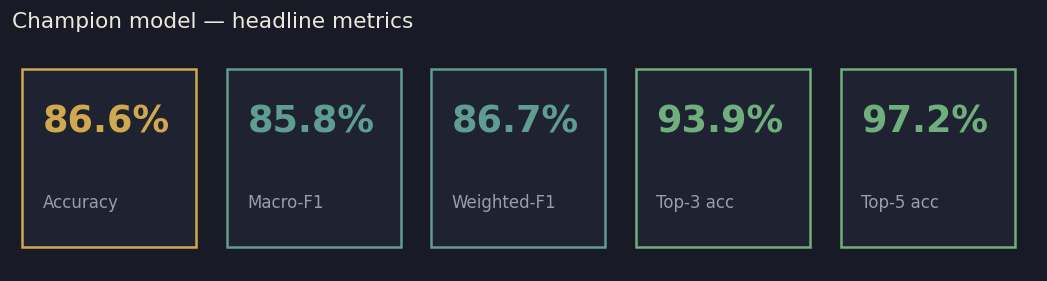

accuracy 0.866 | macro-F1 0.858 | weighted-F1 0.867 | top-3 0.939 | top-5 0.972

macro vs weighted gap: 0.8 pts (bigger gap = thin classes dragging macro down)


In [3]:
acc  = accuracy_score(y_true, y_pred)
mf1  = f1_score(y_true, y_pred, average='macro')
wf1  = f1_score(y_true, y_pred, average='weighted')
# top-k accuracy
def topk_acc(probs, y, k):
    topk = np.argsort(probs, axis=1)[:, -k:]
    return np.mean([y[i] in topk[i] for i in range(len(y))])
t3 = topk_acc(probs, y_true, 3); t5 = topk_acc(probs, y_true, 5)

fig, ax = plt.subplots(figsize=(11,2.4)); ax.axis('off')
cards = [('Accuracy',f'{acc:.1%}',BRASS),('Macro-F1',f'{mf1:.1%}',JADE),
         ('Weighted-F1',f'{wf1:.1%}',JADE),('Top-3 acc',f'{t3:.1%}',GOOD),
         ('Top-5 acc',f'{t5:.1%}',GOOD)]
for i,(lbl,val,c) in enumerate(cards):
    x=i/len(cards)+0.01
    ax.add_patch(plt.Rectangle((x,0.1),1/len(cards)-0.03,0.8,transform=ax.transAxes,
                 facecolor='#1f2230',edgecolor=c,lw=1.5,zorder=1))
    ax.text(x+0.02,0.62,val,transform=ax.transAxes,fontsize=22,fontweight='bold',color=c)
    ax.text(x+0.02,0.28,lbl,transform=ax.transAxes,fontsize=10,color='#9a9caa')
plt.title('Champion model — headline metrics',loc='left',fontsize=13,pad=12); plt.show()

print(f'accuracy {acc:.3f} | macro-F1 {mf1:.3f} | weighted-F1 {wf1:.3f} '
      f'| top-3 {t3:.3f} | top-5 {t5:.3f}')
print(f'\nmacro vs weighted gap: {(wf1-mf1)*100:.1f} pts '
      f'(bigger gap = thin classes dragging macro down)')

## 3 · Per-class F1 — sorted worst → best\nInstantly shows the weak tail versus the strong majority.

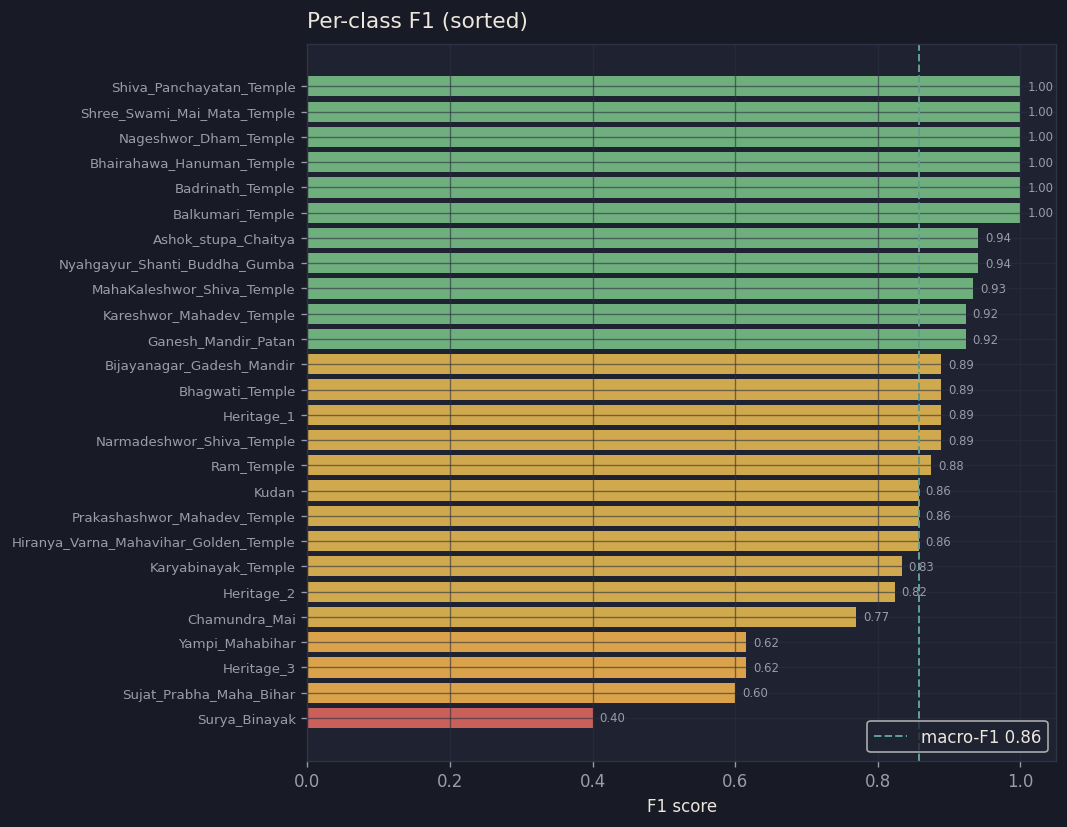

In [4]:
p,r,f,_ = precision_score(y_true,y_pred,average=None,zero_division=0), \
          recall_score(y_true,y_pred,average=None,zero_division=0), \
          f1_score(y_true,y_pred,average=None,zero_division=0), None
order = np.argsort(f)
colors = [BAD if f[i]<0.6 else WARN if f[i]<0.75 else BRASS if f[i]<0.9 else GOOD for i in order]
fig,ax=plt.subplots(figsize=(9, 7))
ax.barh(range(len(order)),[f[i] for i in order],color=colors)
ax.set_yticks(range(len(order))); ax.set_yticklabels([classes[i] for i in order],fontsize=8)
ax.axvline(mf1,color=JADE,ls='--',lw=1.2,label=f'macro-F1 {mf1:.2f}')
ax.set_xlabel('F1 score'); ax.set_xlim(0,1.05); ax.legend(loc='lower right')
ax.set_title('Per-class F1 (sorted)',loc='left',fontsize=13,pad=10)
for i,idx in enumerate(order): ax.text(f[idx]+0.01,i,f'{f[idx]:.2f}',va='center',fontsize=7,color='#9a9caa')
plt.tight_layout(); plt.show()

## 4 · Per-class F1 vs training-set size — the *data-limited* evidence
If the weak classes cluster at low photo counts, performance is limited by **data quantity**, not the model.

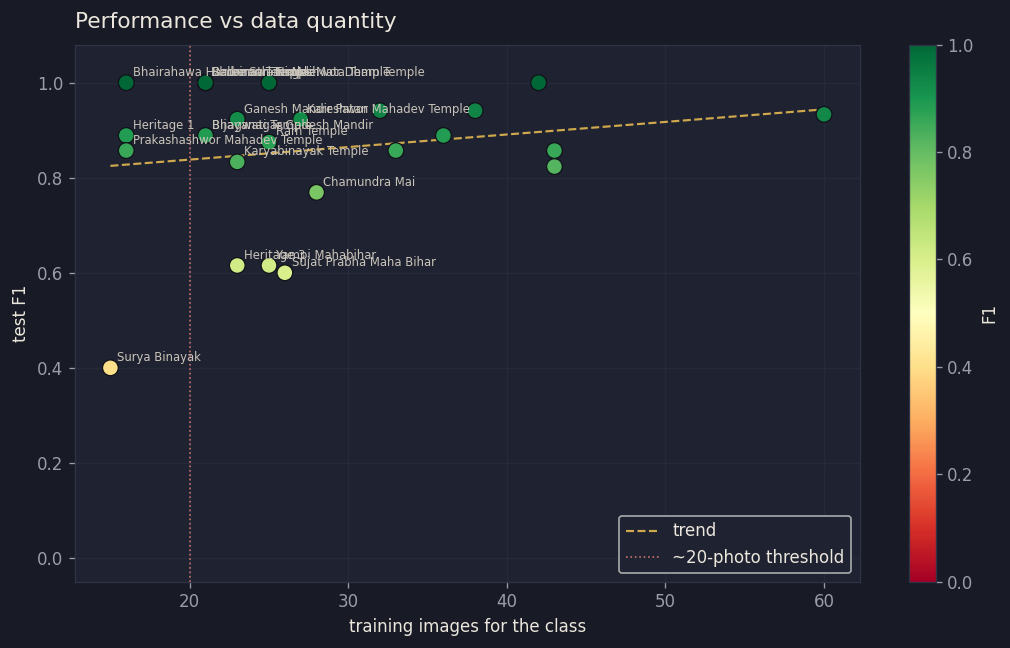

correlation(F1, training size) = 0.19  (positive = more data tends to mean higher F1)


In [5]:
fig,ax=plt.subplots(figsize=(9,5.5))
sc=ax.scatter(sizes, f, s=90, c=f, cmap='RdYlGn', vmin=0, vmax=1,
              edgecolor='#12131b', linewidth=.8, zorder=3)
for i in range(len(classes)):
    if f[i] < 0.75 or sizes[i] < 30:   # label the interesting ones
        ax.annotate(classes[i].replace('_',' '), (sizes[i],f[i]),
                    fontsize=7, color='#c9c4ba', xytext=(4,4), textcoords='offset points')
# trend line
z=np.polyfit(sizes,f,1); xs=np.linspace(sizes.min(),sizes.max(),50)
ax.plot(xs,np.poly1d(z)(xs),color=BRASS,ls='--',lw=1.3,label='trend')
ax.axvline(20,color=ROSE,ls=':',lw=1,label='~20-photo threshold')
ax.set_xlabel('training images for the class'); ax.set_ylabel('test F1')
ax.set_ylim(-0.05,1.08); ax.legend(loc='lower right')
ax.set_title('Performance vs data quantity',loc='left',fontsize=13,pad=10)
plt.colorbar(sc,label='F1'); plt.tight_layout(); plt.show()
corr=np.corrcoef(sizes,f)[0,1]
print(f'correlation(F1, training size) = {corr:.2f}  '
      f'(positive = more data tends to mean higher F1)')

## 5 · Precision vs Recall — magnets vs escapees
Low precision (right, low) = a *magnet* pulling in other sites. Low recall (left) = photos *escaping* to other classes.

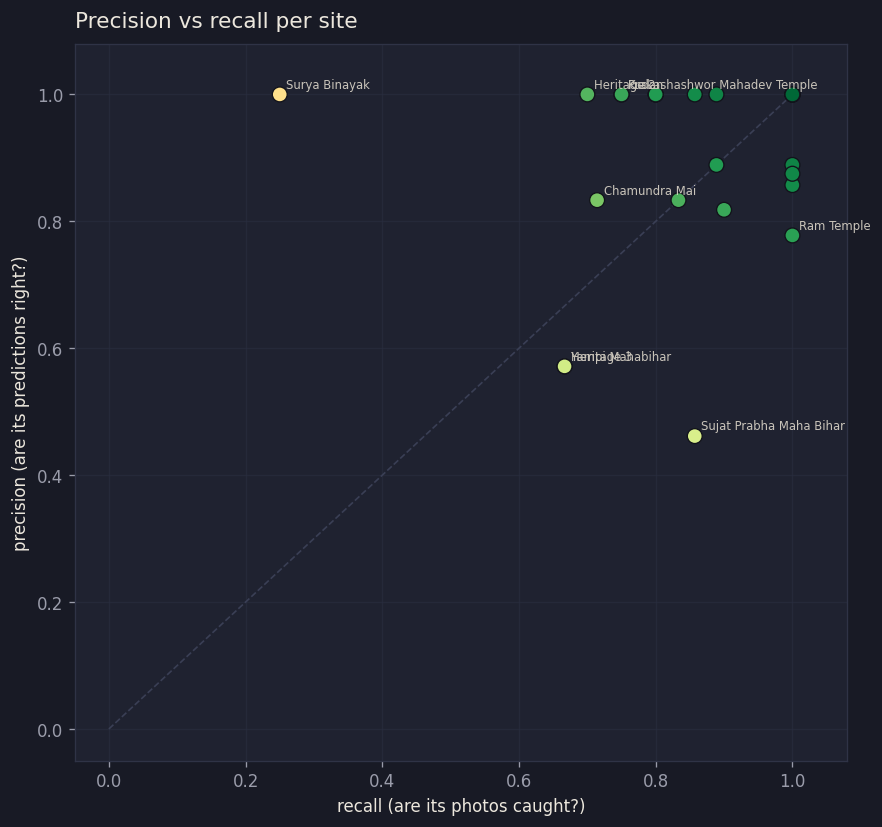

In [6]:
fig,ax=plt.subplots(figsize=(7.5,7))
ax.scatter(r,p,s=80,c=f,cmap='RdYlGn',vmin=0,vmax=1,edgecolor='#12131b',lw=.8,zorder=3)
for i in range(len(classes)):
    if p[i]<0.8 or r[i]<0.8:
        ax.annotate(classes[i].replace('_',' '),(r[i],p[i]),fontsize=7,color='#c9c4ba',
                    xytext=(4,4),textcoords='offset points')
ax.plot([0,1],[0,1],color='#3a3f55',ls='--',lw=1)
ax.set_xlabel('recall (are its photos caught?)'); ax.set_ylabel('precision (are its predictions right?)')
ax.set_xlim(-0.05,1.08); ax.set_ylim(-0.05,1.08)
ax.set_title('Precision vs recall per site',loc='left',fontsize=13,pad=10)
plt.tight_layout(); plt.show()

## 6 · Confusion matrix (row-normalized)

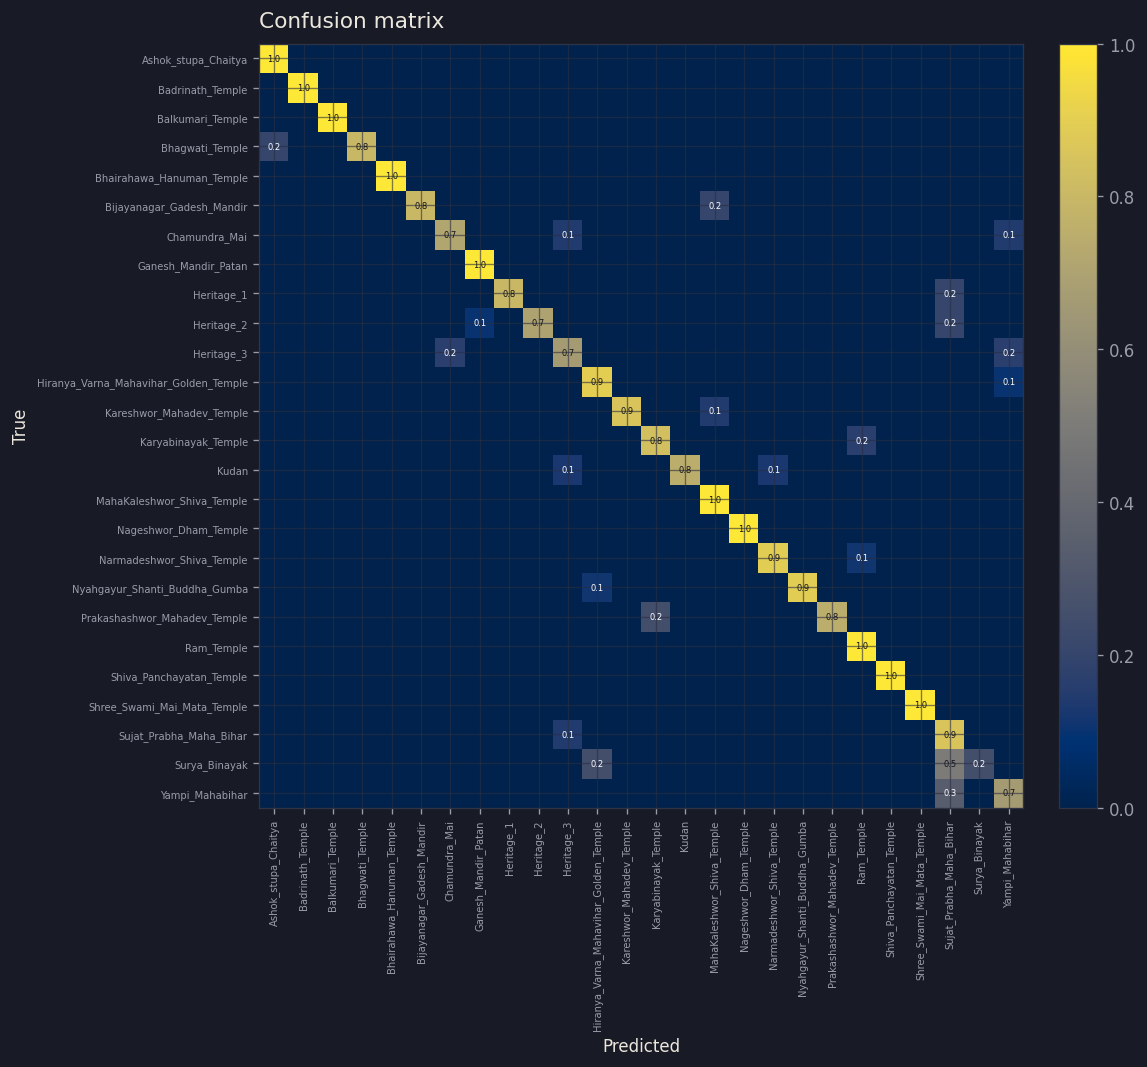

In [7]:
cm=confusion_matrix(y_true,y_pred,labels=range(dm.num_classes))
cmn=np.nan_to_num(cm/cm.sum(1,keepdims=True))
fig,ax=plt.subplots(figsize=(10,9))
im=ax.imshow(cmn,cmap='cividis',vmin=0,vmax=1)
ax.set_xticks(range(dm.num_classes)); ax.set_yticks(range(dm.num_classes))
ax.set_xticklabels(classes,rotation=90,fontsize=6); ax.set_yticklabels(classes,fontsize=6)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for i in range(dm.num_classes):
    for j in range(dm.num_classes):
        if cmn[i,j]>0:
            ax.text(j,i,f'{cmn[i,j]:.1f}',ha='center',va='center',fontsize=5,
                    color='white' if cmn[i,j]<0.5 else '#12131b')
ax.set_title('Confusion matrix',loc='left',fontsize=13,pad=10)
plt.colorbar(im,fraction=0.046,pad=0.04); plt.tight_layout(); plt.show()

## 7 · Confidence analysis
Does the model *know when it's unsure*? Compare confidence on correct vs wrong predictions.

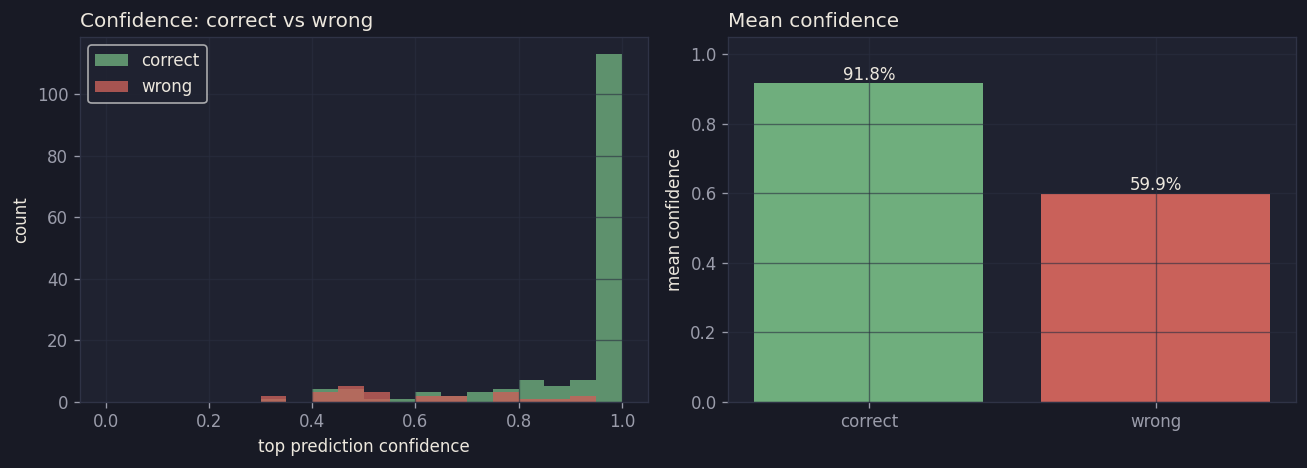

correct preds mean confidence 91.8% | wrong preds 59.9%
larger gap = better-calibrated (model is less sure when it is wrong)


In [8]:
correct = y_true==y_pred
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].hist(pred_conf[correct],bins=20,range=(0,1),color=GOOD,alpha=.8,label='correct')
ax[0].hist(pred_conf[~correct],bins=20,range=(0,1),color=BAD,alpha=.8,label='wrong')
ax[0].set_xlabel('top prediction confidence'); ax[0].set_ylabel('count')
ax[0].legend(); ax[0].set_title('Confidence: correct vs wrong',loc='left',fontsize=12)
# mean bars
mc,mw=pred_conf[correct].mean(),pred_conf[~correct].mean()
ax[1].bar(['correct','wrong'],[mc,mw],color=[GOOD,BAD])
for i,v in enumerate([mc,mw]): ax[1].text(i,v+0.01,f'{v:.1%}',ha='center',color='#ece7dd')
ax[1].set_ylim(0,1.05); ax[1].set_ylabel('mean confidence')
ax[1].set_title('Mean confidence',loc='left',fontsize=12)
plt.tight_layout(); plt.show()
print(f'correct preds mean confidence {mc:.1%} | wrong preds {mw:.1%}')
print('larger gap = better-calibrated (model is less sure when it is wrong)')

## 8 · Threshold trade-off (selective prediction)
If we only answer when confidence ≥ threshold: how does coverage trade against accuracy?

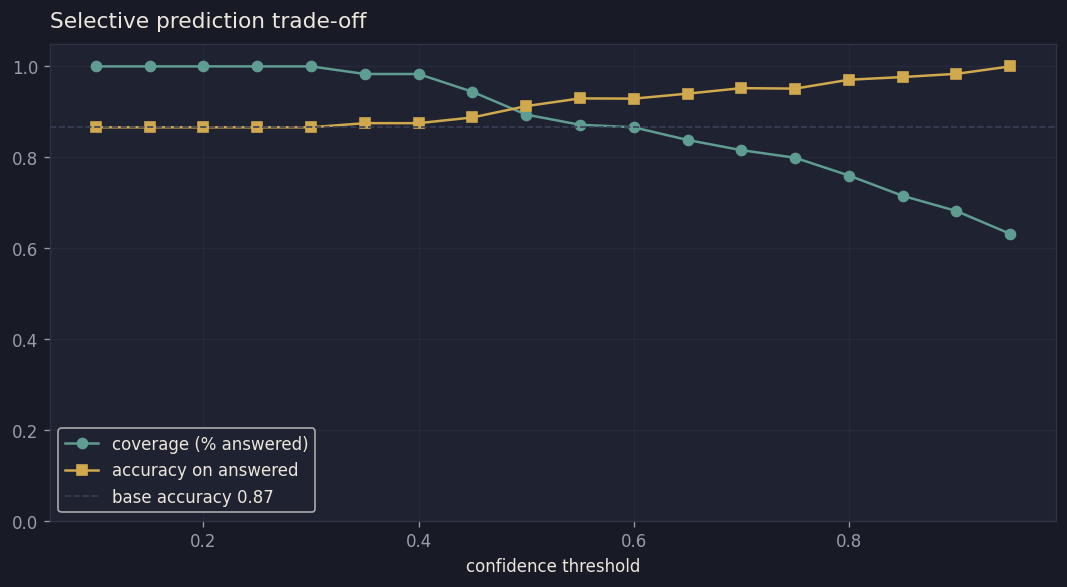

higher threshold -> answers fewer inputs but is more accurate on those it answers


In [9]:
ths=np.linspace(0.1,0.95,18); cov=[]; sel_acc=[]
for t in ths:
    keep=pred_conf>=t
    cov.append(keep.mean())
    sel_acc.append(accuracy_score(y_true[keep],y_pred[keep]) if keep.any() else np.nan)
fig,ax=plt.subplots(figsize=(9,5))
ax.plot(ths,cov,'-o',color=JADE,label='coverage (% answered)')
ax.plot(ths,sel_acc,'-s',color=BRASS,label='accuracy on answered')
ax.axhline(acc,color='#3a3f55',ls='--',lw=1,label=f'base accuracy {acc:.2f}')
ax.set_xlabel('confidence threshold'); ax.set_ylim(0,1.05); ax.legend(loc='lower left')
ax.set_title('Selective prediction trade-off',loc='left',fontsize=13,pad=10)
plt.tight_layout(); plt.show()
print('higher threshold -> answers fewer inputs but is more accurate on those it answers')

## 9 · Strategy comparison (frozen / partial / full)
The experimental result: accuracy rose monotonically with adaptation. (Values from the three runs.)

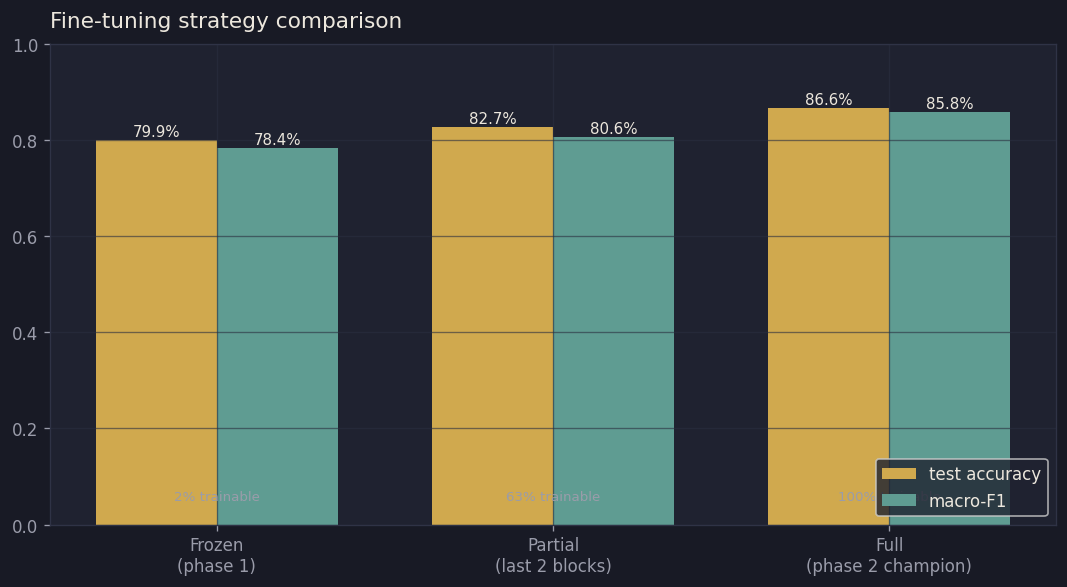

In [10]:
strat=['Frozen\n(phase 1)','Partial\n(last 2 blocks)','Full\n(phase 2 champion)']
acc_s=[0.799,0.827,0.866]; f1_s=[0.784,0.806,0.858]; trainpct=[1.7,62.7,100]
x=np.arange(3); w=0.36
fig,ax=plt.subplots(figsize=(9,5))
b1=ax.bar(x-w/2,acc_s,w,color=BRASS,label='test accuracy')
b2=ax.bar(x+w/2,f1_s,w,color=JADE,label='macro-F1')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.008,f'{b.get_height():.1%}',
            ha='center',fontsize=9,color='#ece7dd')
ax.set_xticks(x); ax.set_xticklabels(strat); ax.set_ylim(0,1.0)
ax.legend(loc='lower right'); ax.set_title('Fine-tuning strategy comparison',loc='left',fontsize=13,pad=10)
for i,tp in enumerate(trainpct):
    ax.text(i,0.05,f'{tp:.0f}% trainable',ha='center',fontsize=8,color='#9a9caa')
plt.tight_layout(); plt.show()

---
### Takeaways (auto-supported by the plots above)
- Champion: **~86.6% accuracy / ~85.8% macro-F1** over 26 sites.
- **Data-limited**: weak classes cluster at low photo counts (§4); tuning didn't beat full fine-tuning (§9).
- **Well-calibrated enough** that a confidence threshold gives a usable "don't know" (§7–8).
- Errors concentrate on a few thin/similar sites; most sites are near-perfect (§3, §6).